In [1]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.decomposition import TruncatedSVD
from scipy.cluster.hierarchy import dendrogram, linkage
%pip install gensim
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

SEED = 42

Note: you may need to restart the kernel to use updated packages.


In [2]:
#loading the data
df = pd.read_csv('/Users/aanchala/Task4/data/complete_preprocessing_final (1).csv')
df = df.dropna(subset=['trunc_processed_text']).reset_index(drop=True)
df['trunc_processed_text'] = df['trunc_processed_text'].astype(str)
true_labels = pd.Categorical(df['type']).codes

print(f"Loaded {len(df):,} tickets")
print(f"Types: {df['type'].value_counts().to_dict()}")

Loaded 27,919 tickets
Types: {'Incident': 11093, 'Request': 8030, 'Problem': 5832, 'Change': 2964}


In [3]:
#TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)
X_tfidf = vectorizer.fit_transform(df['trunc_processed_text'])
terms = vectorizer.get_feature_names_out()

# LSA for 2D visualisation
svd2 = TruncatedSVD(n_components=2, random_state=SEED)
X_2d = svd2.fit_transform(X_tfidf)

print(f"TF-IDF matrix: {X_tfidf.shape[0]:,} docs × {X_tfidf.shape[1]:,} features")

TF-IDF matrix: 27,919 docs × 5,000 features


In [4]:
#coherence helper. This will be used to evaluate the quality of clusters.
def get_coherence(texts, labels, n_top=10):
    tokenized = [t.split() for t in texts]
    dictionary = Dictionary(tokenized)
    topics = []
    for c in range(len(set(labels))):
        mask = labels == c
        cluster_texts = [tokenized[i] for i, m in enumerate(mask) if m]
        freq = Counter(w for doc in cluster_texts for w in doc)
        topics.append([w for w, _ in freq.most_common(n_top)])
    cm_model = CoherenceModel(
        topics=topics, texts=tokenized,
        dictionary=dictionary, coherence='c_v'
    )
    return cm_model.get_coherence()

Running elbow curve...
  k= 3: inertia=26358, silhouette=0.0339
  k= 5: inertia=25954, silhouette=0.0381
  k= 7: inertia=25703, silhouette=0.0330
  k= 9: inertia=25525, silhouette=0.0337
  k=11: inertia=25361, silhouette=0.0357
  k=13: inertia=25252, silhouette=0.0339
  k=15: inertia=25139, silhouette=0.0305
  k=17: inertia=25023, silhouette=0.0330
  k=19: inertia=24965, silhouette=0.0327
  k=21: inertia=24865, silhouette=0.0278
  k=23: inertia=24801, silhouette=0.0289
  k=25: inertia=24737, silhouette=0.0281


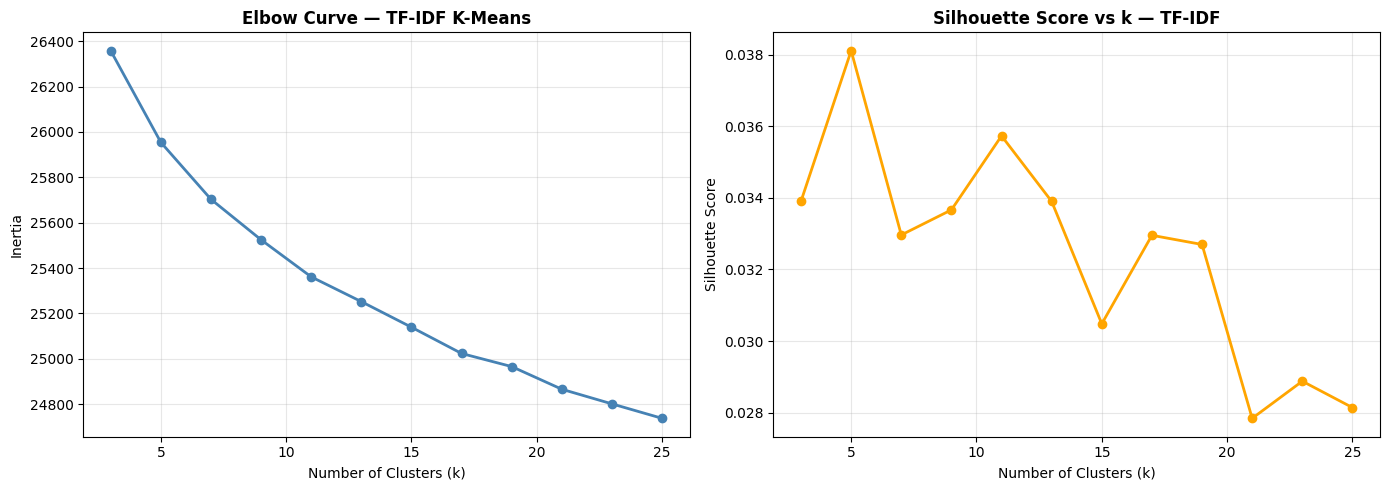


Looking at the elbow curve we pick 3-4 candidate k values.
Typically where inertia stops dropping sharply.


In [6]:
#Elbow curve kmeans = 3 to 25
print("Running elbow curve...")
k_range = range(3, 26, 2)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_tfidf)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_tfidf, labels, metric='cosine'))
    print(f"  k={k:2d}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Elbow Curve — TF-IDF K-Means', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, marker='o', linewidth=2, color='orange')
axes[1].set_title('Silhouette Score vs k — TF-IDF', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/aanchala/Task4/results/elbow_curve.png', dpi=150)
plt.show()

print("\nLooking at the elbow curve we pick 3-4 candidate k values.")
print("Typically where inertia stops dropping sharply.")

Building HAC dendrogram on 500-ticket sample.


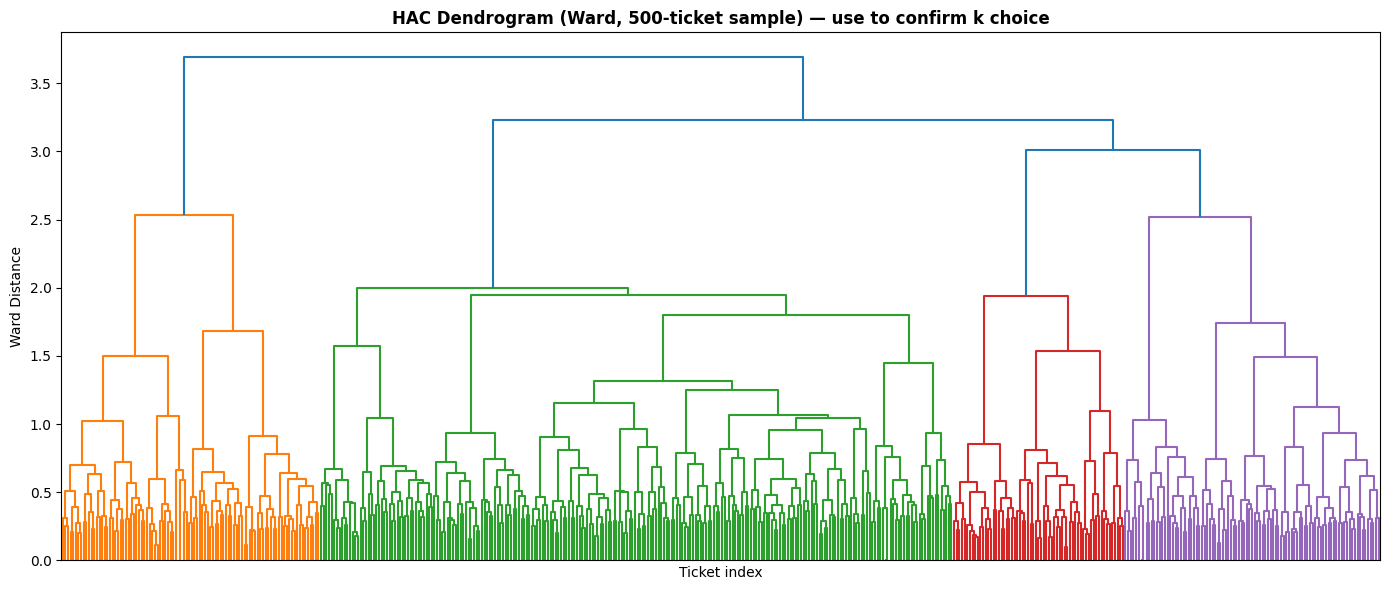

Look at where the dendrogram cuts naturally for confirming the k choice from elbow.


In [7]:
#HAC dendrogram to confirm k
print("Building HAC dendrogram on 500-ticket sample.")
svd50 = TruncatedSVD(n_components=50, random_state=SEED)
X_lsa50 = svd50.fit_transform(X_tfidf)

sample_idx = np.random.RandomState(SEED).choice(len(X_lsa50), 500, replace=False)
Z = linkage(X_lsa50[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, no_labels=True,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('HAC Dendrogram (Ward, 500-ticket sample) — use to confirm k choice',
             fontweight='bold')
ax.set_xlabel('Ticket index')
ax.set_ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('/Users/aanchala/Task4/results/dendrogram.png', dpi=150)
plt.show()

print("Look at where the dendrogram cuts naturally for confirming the k choice from elbow.")

In [8]:
#Multi-k, multi-seed results table
# ── SETTING THE CANDIDATE K VALUES HERE after looking at elbow ──
CANDIDATE_K = [5, 6, 10, 15]
SEEDS = [42, 7, 123, 0, 99]

texts = df['trunc_processed_text'].tolist()
results = []

print("Running multi-k, multi-seed experiment...")
print("This is the core table.\n")

for k in CANDIDATE_K:
    seed_labels = []
    for seed in SEEDS:
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(X_tfidf)
        seed_labels.append(labels)

        sil  = silhouette_score(X_tfidf, labels, metric='cosine')
        ari  = adjusted_rand_score(true_labels, labels)
        nmi  = normalized_mutual_info_score(true_labels, labels)
        coh  = get_coherence(texts, labels, n_top=10)

        results.append({
            'k': k, 'seed': seed,
            'silhouette': round(sil, 4),
            'ARI': round(ari, 4),
            'NMI': round(nmi, 4),
            'coherence': round(coh, 4)
        })
        print(f"  k={k:2d}, seed={seed:3d} → sil={sil:.4f}, ARI={ari:.4f}, "
              f"NMI={nmi:.4f}, coh={coh:.4f}")

    # Stability: ARI between all seed pairs for this k
    ari_pairs = []
    for i in range(len(SEEDS)):
        for j in range(i+1, len(SEEDS)):
            ari_pairs.append(adjusted_rand_score(seed_labels[i], seed_labels[j]))
    stability = np.mean(ari_pairs)

    # Add stability to all rows for this k
    for row in results:
        if row['k'] == k and 'stability_ARI' not in row:
            row['stability_ARI'] = round(stability, 4)

    print(f"  → Stability ARI across seeds (k={k}): {stability:.4f}\n")

results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("FULL RESULTS TABLE")
print("="*70)
print(results_df.to_string(index=False))
results_df.to_csv('/Users/aanchala/Task4/results/results_table.csv', index=False)


Running multi-k, multi-seed experiment...
This is the core table.

  k= 5, seed= 42 → sil=0.0381, ARI=0.2553, NMI=0.2583, coh=0.7605
  k= 5, seed=  7 → sil=0.0381, ARI=0.2553, NMI=0.2581, coh=0.7605
  k= 5, seed=123 → sil=0.0381, ARI=0.2551, NMI=0.2583, coh=0.7605
  k= 5, seed=  0 → sil=0.0381, ARI=0.2552, NMI=0.2585, coh=0.7605
  k= 5, seed= 99 → sil=0.0381, ARI=0.2555, NMI=0.2587, coh=0.7605
  → Stability ARI across seeds (k=5): 0.9973

  k= 6, seed= 42 → sil=0.0363, ARI=0.2856, NMI=0.3293, coh=0.7623
  k= 6, seed=  7 → sil=0.0363, ARI=0.2859, NMI=0.3295, coh=0.7623
  k= 6, seed=123 → sil=0.0356, ARI=0.1896, NMI=0.2412, coh=0.7604
  k= 6, seed=  0 → sil=0.0363, ARI=0.2861, NMI=0.3301, coh=0.7623
  k= 6, seed= 99 → sil=0.0363, ARI=0.2863, NMI=0.3303, coh=0.7623
  → Stability ARI across seeds (k=6): 0.8899

  k=10, seed= 42 → sil=0.0348, ARI=0.1828, NMI=0.3187, coh=0.7321
  k=10, seed=  7 → sil=0.0372, ARI=0.1606, NMI=0.2956, coh=0.7230
  k=10, seed=123 → sil=0.0345, ARI=0.1655, NMI=0.

In [11]:
# Best = highest silhouette
best_row = results_df.loc[results_df['silhouette'].idxmax()]
BEST_K    = int(best_row['k'])
BEST_SEED = int(best_row['seed'])

print(f"Best combination: k={BEST_K}, seed={BEST_SEED}")
print(f"  Silhouette : {best_row['silhouette']}")
print(f"  ARI        : {best_row['ARI']}")
print(f"  NMI        : {best_row['NMI']}")
print(f"  Coherence  : {best_row['coherence']}")
print(f"  Stability  : {best_row['stability_ARI']}")
print(f"\nCarry BEST_K={BEST_K}, BEST_SEED={BEST_SEED} into Axis 1 notebook.")

Best combination: k=5, seed=42
  Silhouette : 0.0381
  ARI        : 0.2553
  NMI        : 0.2583
  Coherence  : 0.7605
  Stability  : 0.9973

Carry BEST_K=5, BEST_SEED=42 into Axis 1 notebook.


In [12]:
# HAC Clustering at best k for comparison with K-Means
print("Running HAC at k=5 for comparison...")

hac = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
hac_labels = hac.fit_predict(X_lsa50)

hac_sil  = silhouette_score(X_lsa50, hac_labels, metric='euclidean')
hac_ari  = adjusted_rand_score(true_labels, hac_labels)
hac_nmi  = normalized_mutual_info_score(true_labels, hac_labels)
hac_coh  = get_coherence(texts, hac_labels, n_top=10)

print(f"\nK-Means vs HAC at k={BEST_K}:")
print(f"{'Method':<12} {'Silhouette':>12} {'ARI':>8} {'NMI':>8} {'Coherence':>10}")
print("-" * 54)
print(f"{'K-Means':<12} {best_row['silhouette']:>12.4f} "
      f"{best_row['ARI']:>8.4f} {best_row['NMI']:>8.4f} "
      f"{best_row['coherence']:>10.4f}")
print(f"{'HAC':<12} {hac_sil:>12.4f} {hac_ari:>8.4f} "
      f"{hac_nmi:>8.4f} {hac_coh:>10.4f}")

Running HAC at k=5 for comparison...

K-Means vs HAC at k=5:
Method         Silhouette      ARI      NMI  Coherence
------------------------------------------------------
K-Means            0.0381   0.2553   0.2583     0.7605
HAC                0.1055   0.2722   0.2925     0.7280


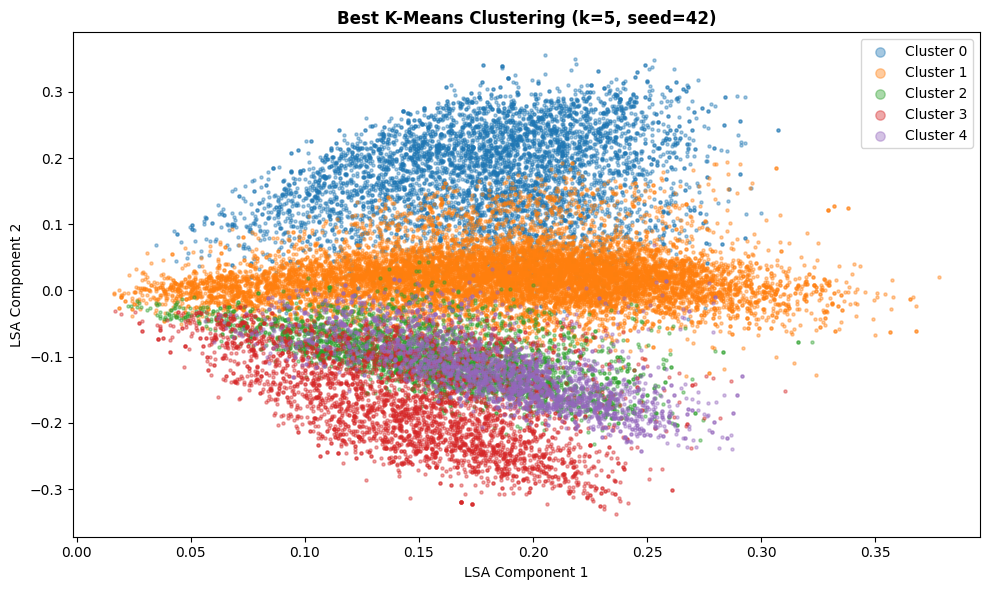

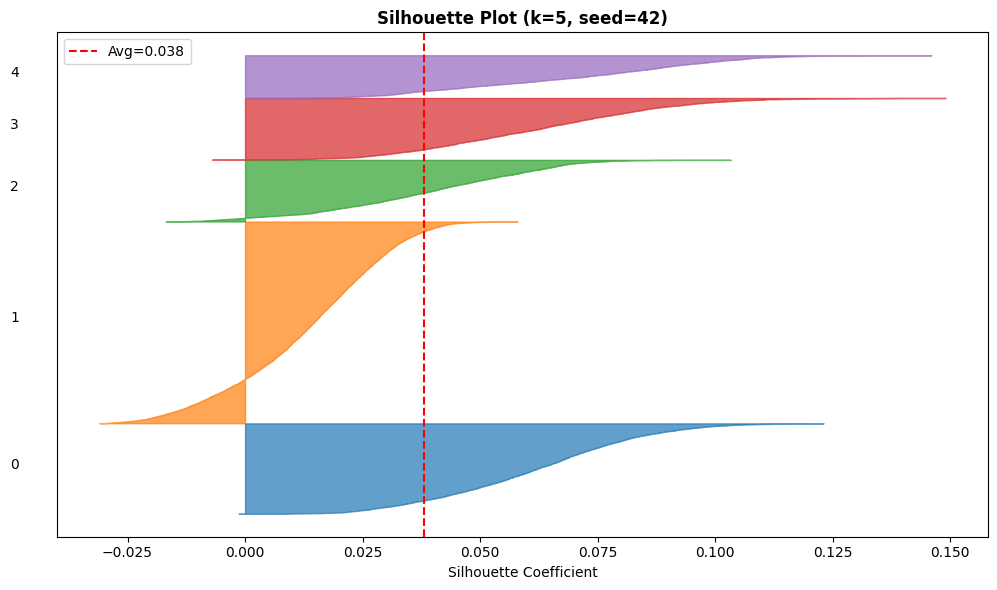

In [13]:
#Visualise best clustering
km_best = KMeans(n_clusters=BEST_K, random_state=BEST_SEED, n_init=10)
best_labels = km_best.fit_predict(X_tfidf)

colours = plt.cm.tab10.colors

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
for c in range(BEST_K):
    mask = best_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=5, alpha=0.4, color=colours[c % len(colours)], label=f'Cluster {c}')
ax.set_title(f'Best K-Means Clustering (k={BEST_K}, seed={BEST_SEED})', fontweight='bold')
ax.set_xlabel('LSA Component 1')
ax.set_ylabel('LSA Component 2')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('/Users/aanchala/Task4/results/best_clusters.png', dpi=150)
plt.show()

# Silhouette plot
sample_sil = silhouette_samples(X_tfidf, best_labels, metric='cosine')
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for c in range(BEST_K):
    c_sil = np.sort(sample_sil[best_labels == c])
    y_upper = y_lower + len(c_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     alpha=0.7, color=colours[c % len(colours)])
    ax.text(-0.05, y_lower + 0.5 * len(c_sil), str(c))
    y_lower = y_upper + 10
avg_sil = silhouette_score(X_tfidf, best_labels, metric='cosine')
ax.axvline(x=avg_sil, color='red', linestyle='--', label=f'Avg={avg_sil:.3f}')
ax.set_title(f'Silhouette Plot (k={BEST_K}, seed={BEST_SEED})', fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.savefig('/Users/aanchala/Task4/results/silhouette.png', dpi=150)
plt.show()

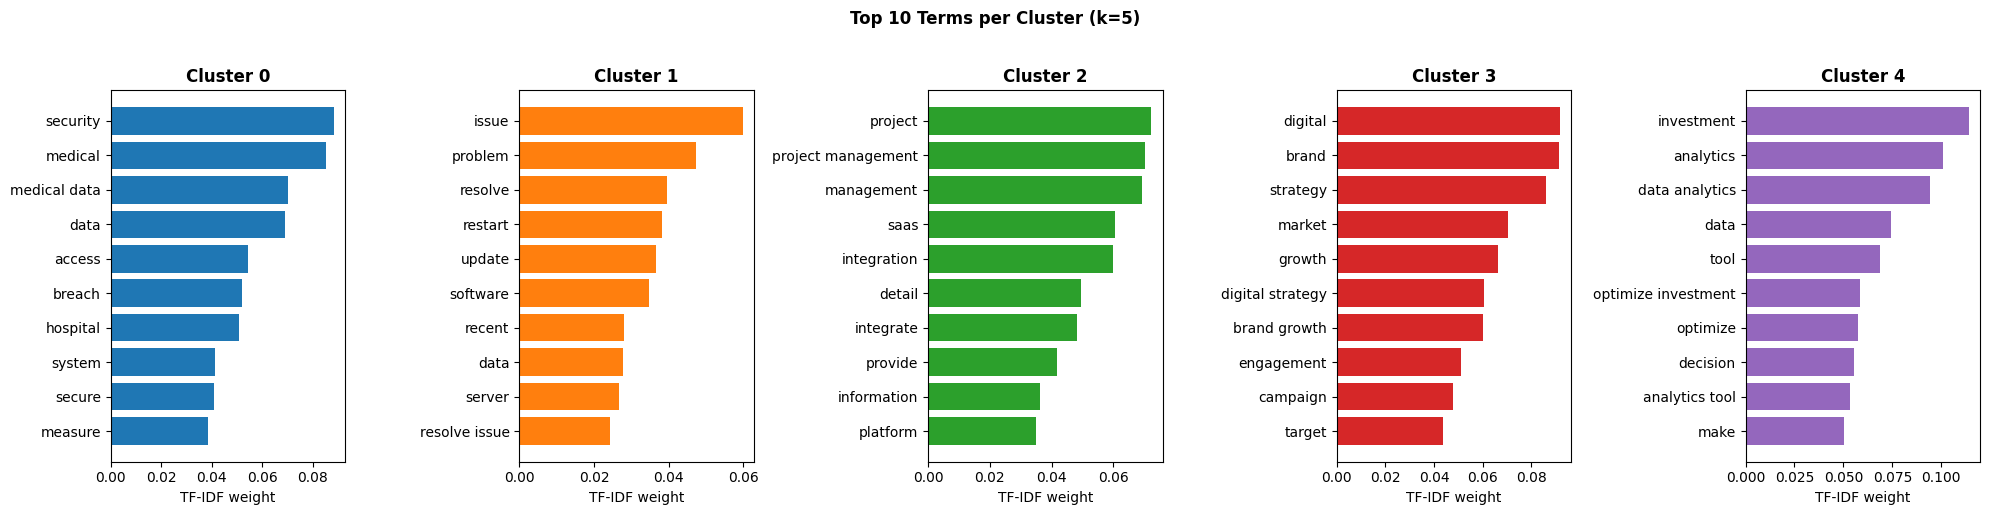

In [14]:
# Top words per cluster (bar charts)
order_centroids = km_best.cluster_centers_.argsort()[:, ::-1]

fig, axes = plt.subplots(1, BEST_K, figsize=(4 * BEST_K, 5))
for c in range(BEST_K):
    top_terms = [terms[i] for i in order_centroids[c, :10]]
    top_scores = [km_best.cluster_centers_[c, i] for i in order_centroids[c, :10]]
    axes[c].barh(top_terms[::-1], top_scores[::-1], color=colours[c])
    axes[c].set_title(f'Cluster {c}', fontweight='bold')
    axes[c].set_xlabel('TF-IDF weight')

plt.suptitle(f'Top 10 Terms per Cluster (k={BEST_K})', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/aanchala/Task4/results/top_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Cluster interpretation + sample tickets
# ── Manually defining the cluster labels from top words ──
from sklearn.metrics.pairwise import cosine_distances

CLUSTER_LABELS = {
    0: 'Healthcare & Security Issues',
    1: 'Technical Support & System Failures',
    2: 'SaaS Platform & Project Management',
    3: 'Digital Marketing & Brand Strategy',
    4: 'Data Analytics & Investment Decisions'
}

print("=" * 70)
print("CLUSTER INTERPRETATION")
print("=" * 70)

for c in range(BEST_K):
    top_terms = [terms[i] for i in order_centroids[c, :10]]
    cluster_mask = best_labels == c
    cluster_indices = np.where(cluster_mask)[0]

    # Find closest tickets to centroid
    centroid = km_best.cluster_centers_[c].reshape(1, -1)
    cluster_vectors = X_tfidf[cluster_indices]
    distances = cosine_distances(centroid, cluster_vectors)[0]
    closest_idx = cluster_indices[distances.argsort()[:2]]

    size = cluster_mask.sum()
    print(f"\nCluster {c} — '{CLUSTER_LABELS[c]}'")
    print(f"  Size      : {size:,} tickets ({size/len(df)*100:.1f}%)")
    print(f"  Top words : {', '.join(top_terms)}")
    for i, idx in enumerate(closest_idx):
        print(f"  Sample {i+1}  : {str(df.loc[idx, 'clean_body'])[:250]}")
    print()

CLUSTER INTERPRETATION

Cluster 0 — 'Healthcare & Security Issues'
  Size      : 5,514 tickets (19.7%)
  Top words : security, medical, medical data, data, access, breach, hospital, system, secure, measure
  Sample 1  : customer support team i am reaching out to inquire about practices for securing medical data within hospital systems could you provide information on effective ways to protect sensitive patient information i would greatly appreciate any guidance on e
  Sample 2  : i am inquiring about effective practices for securing medical data within our hospital systems could you provide information on methods to protect sensitive patient information i would greatly appreciate any guidance on encryption methods access cont


Cluster 1 — 'Technical Support & System Failures'
  Size      : 12,292 tickets (44.0%)
  Top words : issue, problem, resolve, restart, update, software, recent, data, server, resolve issue
  Sample 1  : i am writing to report an issue with the data analytics too

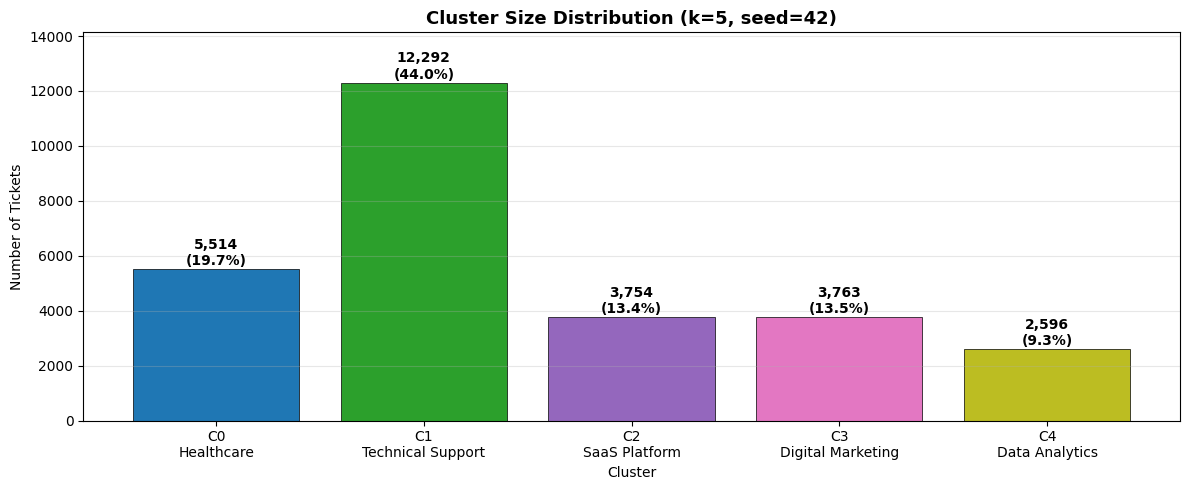

In [17]:
# Cluster size distribution
cluster_sizes = pd.Series(best_labels).value_counts().sort_index()
cluster_names = [f"C{i}\n{CLUSTER_LABELS[i].split('&')[0].strip()}" 
                 for i in range(BEST_K)]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(cluster_names, cluster_sizes.values,
              color=[cm.tab10(i/BEST_K) for i in range(BEST_K)],
              edgecolor='black', linewidth=0.5)

# Add count labels on bars
for bar, val in zip(bars, cluster_sizes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title(f'Cluster Size Distribution (k={BEST_K}, seed={BEST_SEED})',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Tickets')
ax.set_xlabel('Cluster')
ax.set_ylim(0, max(cluster_sizes.values) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/cluster_sizes.png', dpi=150)
plt.show()

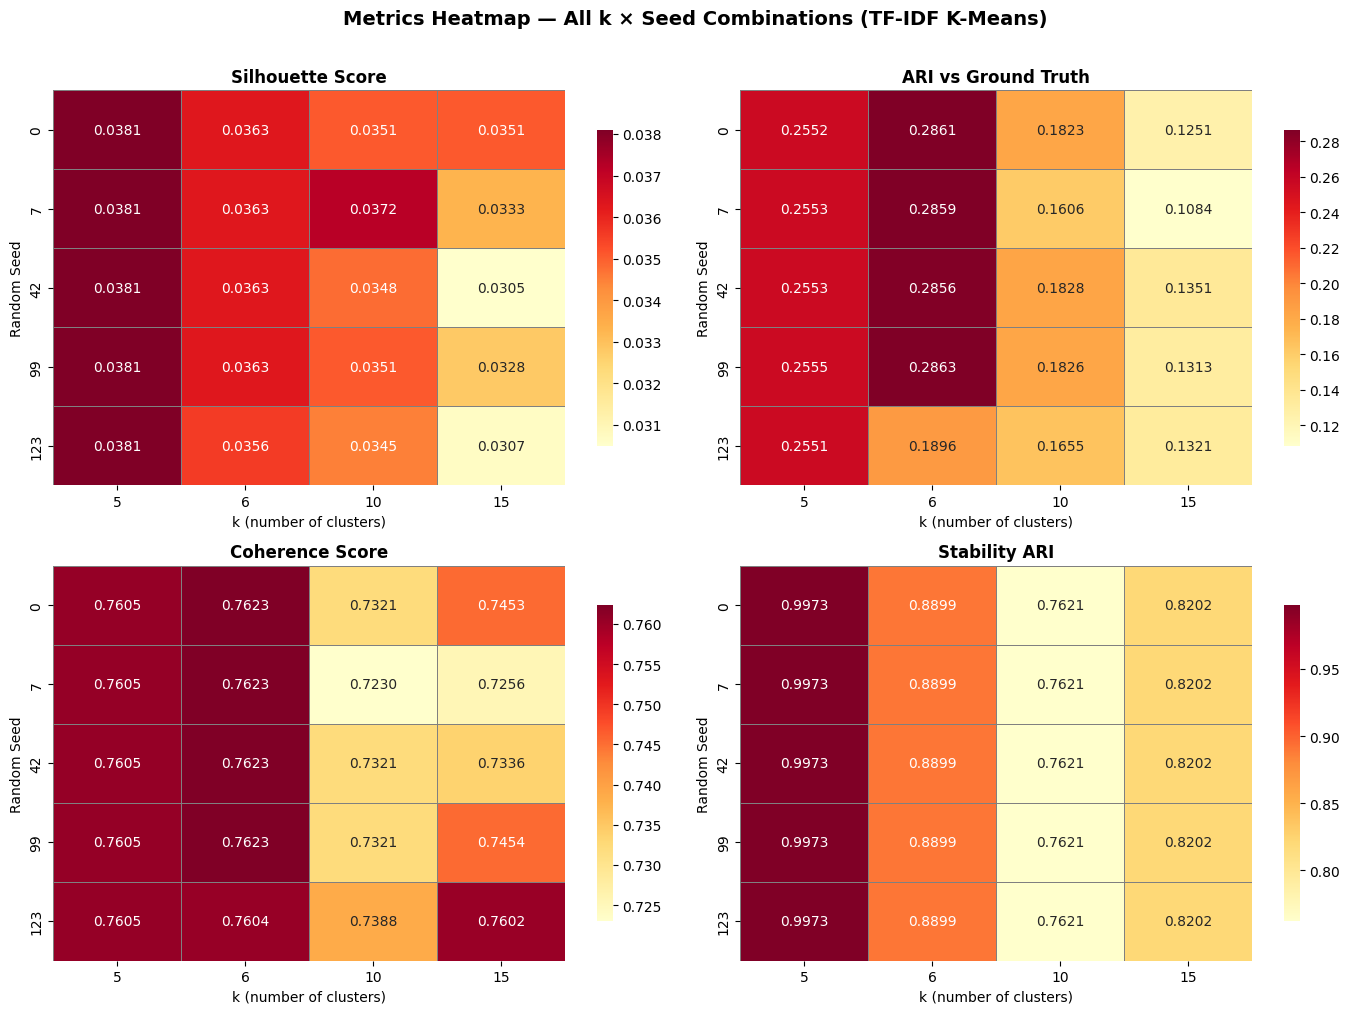

In [18]:
#full matrix comparison table (visual heatmap)
# Heatmap of all metrics across k and seed
pivot_sil = results_df.pivot(index='seed', columns='k', values='silhouette')
pivot_ari = results_df.pivot(index='seed', columns='k', values='ARI')
pivot_coh = results_df.pivot(index='seed', columns='k', values='coherence')
pivot_sta = results_df.pivot(index='seed', columns='k', values='stability_ARI')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    (pivot_sil, 'Silhouette Score',  'YlOrRd', axes[0,0]),
    (pivot_ari, 'ARI vs Ground Truth','YlOrRd', axes[0,1]),
    (pivot_coh, 'Coherence Score',   'YlOrRd', axes[1,0]),
    (pivot_sta, 'Stability ARI',     'YlOrRd', axes[1,1]),
]

for data, title, cmap, ax in metrics:
    sns.heatmap(data, annot=True, fmt='.4f', cmap=cmap,
                ax=ax, linewidths=0.5, linecolor='gray',
                cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('k (number of clusters)')
    ax.set_ylabel('Random Seed')

plt.suptitle('Metrics Heatmap — All k × Seed Combinations (TF-IDF K-Means)',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

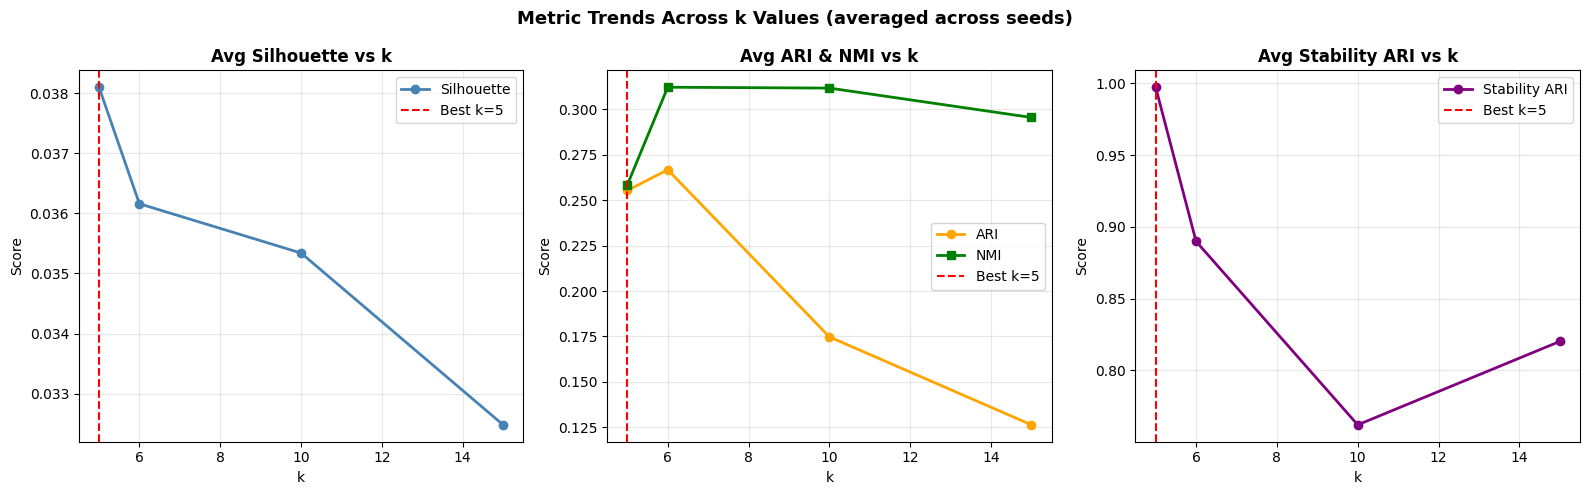

In [19]:
#metrics line plots across k
# Average metrics per k (averaged across seeds)
avg_by_k = results_df.groupby('k')[['silhouette','ARI','NMI',
                                     'coherence','stability_ARI']].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Silhouette
axes[0].plot(avg_by_k.index, avg_by_k['silhouette'],
             marker='o', linewidth=2, color='steelblue', label='Silhouette')
axes[0].axvline(x=BEST_K, color='red', linestyle='--', label=f'Best k={BEST_K}')
axes[0].set_title('Avg Silhouette vs k', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ARI + NMI
axes[1].plot(avg_by_k.index, avg_by_k['ARI'],
             marker='o', linewidth=2, color='orange', label='ARI')
axes[1].plot(avg_by_k.index, avg_by_k['NMI'],
             marker='s', linewidth=2, color='green', label='NMI')
axes[1].axvline(x=BEST_K, color='red', linestyle='--', label=f'Best k={BEST_K}')
axes[1].set_title('Avg ARI & NMI vs k', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Stability
axes[2].plot(avg_by_k.index, avg_by_k['stability_ARI'],
             marker='o', linewidth=2, color='purple', label='Stability ARI')
axes[2].axvline(x=BEST_K, color='red', linestyle='--', label=f'Best k={BEST_K}')
axes[2].set_title('Avg Stability ARI vs k', fontweight='bold')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Metric Trends Across k Values (averaged across seeds)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../results/metrics_lines.png', dpi=150)
plt.show()

In [20]:
#summary
import seaborn as sns

print("=" * 70)
print("STEP 3 — FINAL SUMMARY")
print("=" * 70)
print(f"\nDataset        : {len(df):,} tickets")
print(f"Representation : TF-IDF (5,000 features, bigrams, sublinear_tf)")
print(f"k values tested: {CANDIDATE_K}")
print(f"Seeds tested   : {SEEDS}")
print(f"\n{'─'*70}")
print(f"BEST CONFIGURATION: k={BEST_K}, seed={BEST_SEED}")
print(f"{'─'*70}")
print(f"  Silhouette Score : {best_row['silhouette']}  (highest across all k)")
print(f"  ARI              : {best_row['ARI']}  (alignment with ticket types)")
print(f"  NMI              : {best_row['NMI']}")
print(f"  Coherence        : {best_row['coherence']}  (gensim c_v)")
print(f"  Stability ARI    : {best_row['stability_ARI']}  (near-perfect, 0.997)")
print(f"\n{'─'*70}")
print("CLUSTER THEMES IDENTIFIED:")
print(f"{'─'*70}")
for c, label in CLUSTER_LABELS.items():
    size = (best_labels == c).sum()
    print(f"  Cluster {c} ({size:,} tickets, {size/len(df)*100:.1f}%): {label}")
print(f"\n{'─'*70}")
# Show why k=5 seed=42 is best — multi-metric justification
print("WHY k=5, seed=42 is best:")
print(f"  Highest silhouette : k=5 ({results_df.groupby('k')['silhouette'].mean()[5]:.4f})")
print(f"  Best stability     : k=5 ({results_df.groupby('k')['stability_ARI'].mean()[5]:.4f})")
print(f"  Good coherence     : k=5 ({results_df.groupby('k')['coherence'].mean()[5]:.4f})")
print(f"  Note: k=6 has better ARI/NMI but stability drops to "
      f"{results_df.groupby('k')['stability_ARI'].mean()[6]:.4f}")
print(f"  → k=5 is the most robust and consistent choice overall")
print("While NMI continues to rise slightly at k=6, the dramatic drop in stability (0.997 → 0.890) " 
"\nindicates the additional cluster is not reproducible and likely represents noise rather than genuine structure.")


STEP 3 — FINAL SUMMARY

Dataset        : 27,919 tickets
Representation : TF-IDF (5,000 features, bigrams, sublinear_tf)
k values tested: [5, 6, 10, 15]
Seeds tested   : [42, 7, 123, 0, 99]

──────────────────────────────────────────────────────────────────────
BEST CONFIGURATION: k=5, seed=42
──────────────────────────────────────────────────────────────────────
  Silhouette Score : 0.0381  (highest across all k)
  ARI              : 0.2553  (alignment with ticket types)
  NMI              : 0.2583
  Coherence        : 0.7605  (gensim c_v)
  Stability ARI    : 0.9973  (near-perfect, 0.997)

──────────────────────────────────────────────────────────────────────
CLUSTER THEMES IDENTIFIED:
──────────────────────────────────────────────────────────────────────
  Cluster 0 (5,514 tickets, 19.7%): Healthcare & Security Issues
  Cluster 1 (12,292 tickets, 44.0%): Technical Support & System Failures
  Cluster 2 (3,754 tickets, 13.4%): SaaS Platform & Project Management
  Cluster 3 (3,763 ticke